In [5]:
import pandas as pd
from google.colab import files

In [6]:
#uploaded = files.upload()

In [4]:
# Replace 'path_to_file.xlsx' with your actual file path
df = pd.read_excel('FRE_DPR_Cumulative.xlsx')
df['CPR']

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,CPR
0,0.889
1,0.576
2,0.739
3,0.381
4,0.357
...,...
450354,0.000
450355,0.000
450356,0.000
450357,0.000


In [7]:
df['CPR']#just to upload:
#from google.colab import files

,CPR
0,0.889
1,0.576
2,0.739
3,0.381
4,0.357
...,...
450354,0.000
450355,0.000
450356,0.000
450357,0.000


In [8]:
#Converting SMM into CPR.
df['SMM_calc'] = (df['Unscheduled Principal Reduction Amount'] / df['Cohort Current UPB'])
df['CPR_calc'] = (1-(1-(df['SMM_calc']))**12)
df['CPR_calc'] *=100 #empircal cpr

In [32]:
#data testing
(df['CPR_calc'] == 0).sum()
(df['CPR_calc'] == 0).mean()
df[df['CPR_calc'] == 0].iloc[0]
df[df['CPR_calc'] == 0].head() #boolean mask and filter rows.

,Type of Security,Year,WA Net Interest Rate,Cohort Current UPB,Cohort WA Current Interest Rate,Cohort WA Current Remaining Months to Maturity,Cohort WA Current Loan Age,Date,Factor Date,Principal Reduction Amount,...,CPR,Cumulative CPR,SMM_calc,CPR_calc,refinancing incentive_calc,age_bucket,CPR_min,CPR_max,CPR_model,SMM_model
2663,Super-Conforming > 15yr,2016,3,4.479786e+09,3.735,327,29,01/08/2019,02/2019,2149.53,...,0.0,0.308,0.0,0.0,-0.02265,0-5y,0.359671,0.468923,0.363208,0.036911
2859,Other Fixed-Rate > 15yr,2013,3,1.335491e+09,3.664,245,70,01/25/2019,02/2019,604.53,...,0.0,2.306,0.0,0.0,-0.02336,5-10y,0.359671,0.468923,0.362861,0.036867
5085,20yr TBA Eligible,2014,3,6.340719e+08,3.813,182,53,02/26/2019,03/2019,41.68,...,0.0,2.849,0.0,0.0,-0.02187,0-5y,0.359671,0.468923,0.363631,0.036964
5886,15yr TBA Eligible,2018,2.5,8.006170e+08,3.267,164,12,02/08/2019,03/2019,2987.77,...,0.0,0.828,0.0,0.0,-0.02733,0-5y,0.359671,0.468923,0.361453,0.036690
7129,30yr TBA Eligible,2005,4.5,5.964111e+08,5.251,184,164,03/27/2019,04/2019,181.15,...,0.0,6.113,0.0,0.0,-0.00749,10-15y,0.359671,0.468923,0.386478,0.039894


In [31]:
df[df['CPR']==0].iloc[0]
#CPR is 0, since no prepayment was made at this factor date. however, we see CPR cumulative as 30 percent meaning prepayment made 30 percent so far of original balance.

,2432
Type of Security,15yr TBA Eligible
Year,2016
WA Net Interest Rate,3.5
Cohort Current UPB,931944707.88
Cohort WA Current Interest Rate,4.108
Cohort WA Current Remaining Months to Maturity,141
Cohort WA Current Loan Age,32
Date,01/11/2019
Factor Date,02/2019
Principal Reduction Amount,385.88


In [11]:
#Desiging a forward looking CPR from emprical Cpr.
#we make a forward looking model using It = c - rt with incentives to refiannce.
#c= mortgage coupon
#From the current data: Cohort WA Current Interest Rate is.
#from data, fixed rate = Cohort WA Current Interest Rate.
#current mortgage arte.

In [33]:
#refinance incentive:
df['refinancing incentive_calc'] = (df['Cohort WA Current Interest Rate']/100) - 0.06

In [13]:
df['refinancing incentive_calc']
#data understanding: 0.01384 = borrower has + 1.3 % higher incentive to refinance. #It is computed.

,refinancing incentive_calc
0,0.01384
1,0.01384
2,0.01384
3,0.01384
4,0.01384
...,...
450354,-0.00412
450355,-0.00412
450356,-0.00412
450357,-0.00412


In [14]:
#this one not needed atm. just capturing current instaneous Rates.
#import requests
#import pandas as pd

#API_KEY = #
#series_id = "MORTGAGE30US"

#url = "https://api.stlouisfed.org/fred/series/observations"
#params = {
#    "series_id": series_id,
#    "api_key": API_KEY,
#    "file_type": "json"
#}

#r = requests.get(url, params=params, timeout=30)
#data = r.json()["observations"]
#rates = pd.DataFrame(data)[["date", "value"]]

# clean
#rates["date"] = pd.to_datetime(rates["date"])
#rates["r_t"] = pd.to_numeric(rates["value"], errors="coerce")
#rates = rates.drop(columns=["value"])
#rates = rates.dropna(subset=["r_t"])
#rates = rates.sort_values("date")

# latest rate
#current_rate = rates.iloc[-1]["r_t"]
#print("Current mortgage rate:", current_rate)
#print(rates.tail()) #weekly snapshot (may have some limitation)

Current mortgage rate: 6.46
           date   r_t
2866 2026-03-05  6.00
2867 2026-03-12  6.11
2868 2026-03-19  6.22
2869 2026-03-26  6.38
2870 2026-04-02  6.46


In [15]:
#Then, we design a forward conditional prepapyment rate.
#CPR(forward) = CPR(min)

In [16]:
#data checking.
df['refinancing incentive_calc'].mean()
df['Cohort WA Current Loan Age'].mean()

np.float64(-0.017099107867279213)

In [18]:
scohort_view = df[[
    'Cohort WA Current Loan Age',
    'Cohort WA Current Interest Rate',
    'Cohort Current UPB'
]].drop_duplicates().reset_index(drop=True)

In [19]:
(df['CPR_calc'] == 0).sum()

np.int64(70744)

In [34]:
df['age_bucket'] = pd.cut(
    df['Cohort WA Current Loan Age'],
    bins=[0, 60, 120, 180, 240, 360],
    labels=['0-5y','5-10y','10-15y','15-20y','20y+']
)
grouped = df.groupby('age_bucket')
CPR_min_age = grouped.apply(
    lambda x: x[x['refinancing incentive_calc'] < -0.005]['CPR_calc']
)
CPR_max_age = grouped.apply(
    lambda x: x[x['refinancing incentive_calc'] > 0.01]['CPR_calc'].mean()
)

/tmp/ipykernel_26279/3021165393.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('age_bucket')
/tmp/ipykernel_26279/3021165393.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  CPR_min_age = grouped.apply(
/tmp/ipykernel_26279/3021165393.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclud

In [21]:
CPR_min_age.value_counts()
df.dtypes

,0
Type of Security,object
Year,int64
WA Net Interest Rate,object
Cohort Current UPB,float64
Cohort WA Current Interest Rate,float64
Cohort WA Current Remaining Months to Maturity,int64
Cohort WA Current Loan Age,int64
Date,object
Factor Date,object
Principal Reduction Amount,float64


In [35]:
CPR_max_age #currently the min and max range are not accurate.
#min and max should be based on collateral structure like loan level or balance.


,0
age_bucket,
0-5y,0.786293
5-10y,NaN
10-15y,0.583541
15-20y,0.467619
20y+,0.497815


In [36]:
CPR_min_age

age_bucket        
0-5y        992       0.145118
            993       0.173795
            994       0.230487
            995       0.198975
            996       0.155126
                        ...   
20y+        445026    0.059319
            445027    0.290743
            445028    0.156115
            445029    0.183213
            445030    0.259410
Name: CPR_calc, Length: 377536, dtype: float64

In [37]:
monthly = df.groupby([
    'Cohort WA Current Remaining Months to Maturity',
    'Factor Date'
]).agg({
    'CPR_calc': 'mean',
    'SMM_calc': 'mean',
    'Cohort WA Current Interest Rate': 'first',
    'Cohort Current UPB': 'first'
}).reset_index()


In [38]:
df.columns

Index(['Type of Security', 'Year', 'WA Net Interest Rate',
       'Cohort Current UPB', 'Cohort WA Current Interest Rate',
       'Cohort WA Current Remaining Months to Maturity',
       'Cohort WA Current Loan Age', 'Date', 'Factor Date',
       'Principal Reduction Amount', 'Cumulative Principal Reduction Amount',
       'Unscheduled Principal Reduction Amount',
       'Cumulative Unscheduled Principal Reduction Amount', 'SMM',
       'Cumulative SMM', 'CPR', 'Cumulative CPR', 'SMM_calc', 'CPR_calc',
       'refinancing incentive_calc', 'age_bucket', 'CPR_min', 'CPR_max',
       'CPR_model', 'SMM_model'],
      dtype='object')

In [39]:
low = df[df['refinancing incentive_calc'] < -0.005]['CPR_calc']
high = df[df['refinancing incentive_calc'] > 0.01]['CPR_calc']
CPR_min = low.mean()
CPR_max = high.mean()
print(CPR_min, CPR_max)

0.58072929023838 0.6884684323088095


In [40]:
high

,CPR_calc
0,0.883718
1,0.571493
2,0.734905
3,0.377933
4,0.354316
...,...
447546,1.303825
447547,0.000000
447548,0.848598
447549,0.000000


In [41]:
#there are two strategies to design min CPR and max CPR. from incentives to quantile range. for now we do quantile range.
q20 = df['refinancing incentive_calc'].quantile(0.2) #isit right to have / use 20 quantile and 80 quantile?
q80 = df['refinancing incentive_calc'].quantile(0.8)

df['CPR_min'] = df[df['refinancing incentive_calc'] <= q20]['CPR_calc'].mean()
df['CPR_max'] = df[df['refinancing incentive_calc'] >= q80]['CPR_calc'].mean()

print(CPR_min, CPR_max)

0.58072929023838 0.6884684323088095


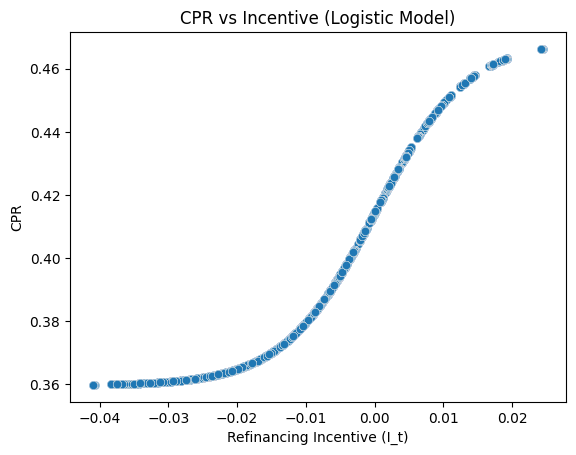

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
k = 150      # steepness (tune later)
theta = 0   # midpoint

df['CPR_model'] = df['CPR_min'] + (
    (df['CPR_max'] - df['CPR_min']) *
    (1 / (1 + np.exp(-k * (df['refinancing incentive_calc'] - theta))))
)
df['SMM_model'] = 1 - (1 - df['CPR_model'])**(1/12)
df[['CPR_min', 'CPR_model', 'CPR_max']].head()

import seaborn as sns
sns.scatterplot(
    x='refinancing incentive_calc',
    y='CPR_model',
    data=df,
    alpha=0.1
)
plt.xlabel('Refinancing Incentive (I_t)')
plt.ylabel('CPR')
plt.title('CPR vs Incentive (Logistic Model)')
plt.show()
